In [2]:
import os.path
import numpy as np
import math
from soundfile import SoundFile
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.fft import fft, fftfreq

In [3]:
def bpdbe_read_audio(fn):
    """function reads Doppler 1D data from BP_DBE Wav audio file"""
    w = SoundFile(fn)
    samples = w.frames
    signal = w.read(samples)
    signal = np.frombuffer(signal, dtype=float)
    w.close()
    return signal

In [4]:
DATA_PATH = r'C:\Users\hsmach\Dropbox\Hanna.Smach\US_workshop_FUW_2023\2022-zdrowi-NIKARD'

T_RANGE = 70        # time scale range [s]
F_RANGE = 2000      # freq range [Hz]
AUDIO_FS = 32e3     # fixed Audio-Doppler sampling rate
filt_freq_lower = 100  # [Hz]
filt_freq_upper = 2000 # [Hz]

In [5]:
listOfFiles = os.listdir(DATA_PATH)
idx=3

# read data
fn_dop = os.path.join(DATA_PATH,listOfFiles[idx])
print(listOfFiles[idx])
doppler = bpdbe_read_audio(fn_dop)

N = len(doppler)
T = 1/AUDIO_FS
dop_time=np.linspace(0, N*T, len(doppler))

dop220207043494.wav


In [6]:
# Fast Fourier Transform
fft_dop = fft(doppler)
freqs_dop = fftfreq(N,T)
i_sorted = np.argsort(freqs_dop)
ps = np.abs(fft_dop)**2

# FILTRATION in frequnecy domain - optional
filter_range = np.ndarray.tolist(np.where(np.logical_and(freqs_dop>filt_freq_lower, freqs_dop<filt_freq_upper))[0])
fft_dop_filtered = fft_dop[filter_range]
freqs_dop_filtered = freqs_dop[filter_range]

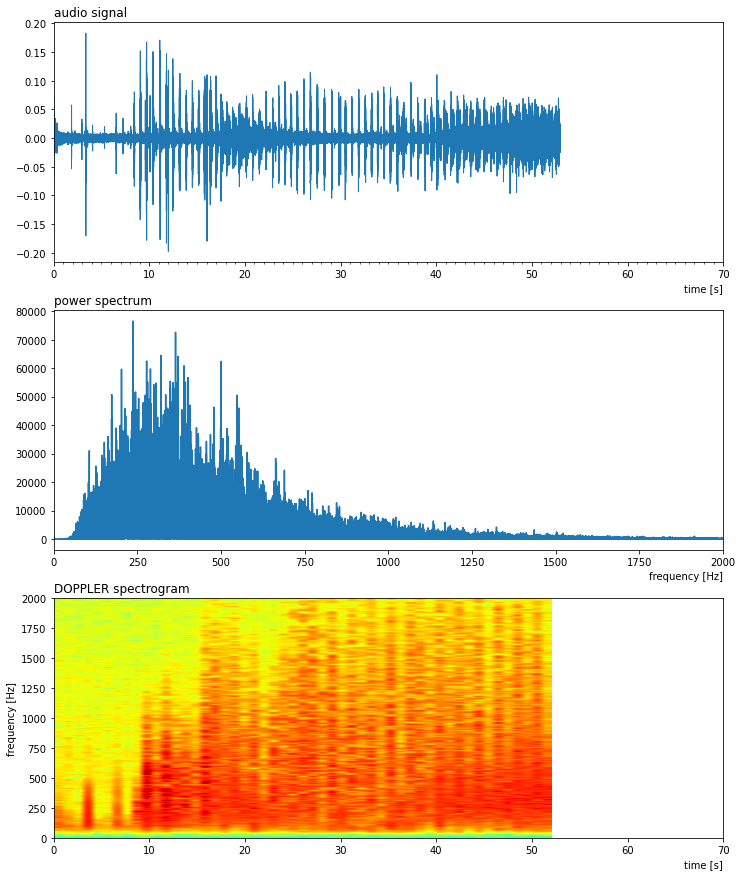

In [7]:
fig, axs = plt.subplots(3, figsize=(12, 15))
## Plot RAW SIGNAL in time domain
axs[0].set_title('audio signal',loc='left')
axs[0].set_xlabel('time [s]',loc='right')
# axs[0].set_ylabel('...')
axs[0].set_xlim(0, T_RANGE)
axs[0].set_xticks(range(0,T_RANGE), minor=True)
axs[0].plot(dop_time, doppler, linewidth=1, linestyle="-", label=str(idx))

## Plot POWER SPECTRUM (one-sided)
axs[1].set_title('power spectrum',loc='left')
axs[1].set_xlabel('frequency [Hz]',loc='right')
axs[1].set_xlim(0,F_RANGE)
axs[1].plot(freqs_dop[i_sorted], ps[i_sorted])

## Plot SPECTROGRAM
axs[2].set_title('DOPPLER spectrogram',loc='left')
axs[2].set_xlabel('time [s]',loc='right')
axs[2].set_ylabel('frequency [Hz]')
NFFT = 1024*32
# (Pxx, freqs, bins, im) = axs[2].specgram(doppler, NFFT=NFFT, Fs=AUDIO_FS, noverlap=int(NFFT*.5), scale='dB', cmap="jet")
(Pxx, freqs, bins, im) = axs[2].specgram(doppler, NFFT=NFFT, Fs=AUDIO_FS, noverlap=None, scale='dB', cmap="jet")
axs[2].set_ylim(0,F_RANGE)
axs[2].set_xlim(0, T_RANGE)

plt.show()

In [8]:
# VELOCITY CALCULATION
speed_of_sound = 1540   # [m/s]
theta=0                 # angle correction [rad]
f0= 8e6                 # [Hz]

fD=freqs
v=speed_of_sound*fD/(2*f0*math.cos(theta))
v   # [m/s]

array([0.00000000e+00, 9.39941406e-05, 1.87988281e-04, ...,
       1.53981201e+00, 1.53990601e+00, 1.54000000e+00])

In [9]:
def convert_to_velo(f):
    return 100*speed_of_sound*f/(2*f0*math.cos(theta))  # [cm/s]

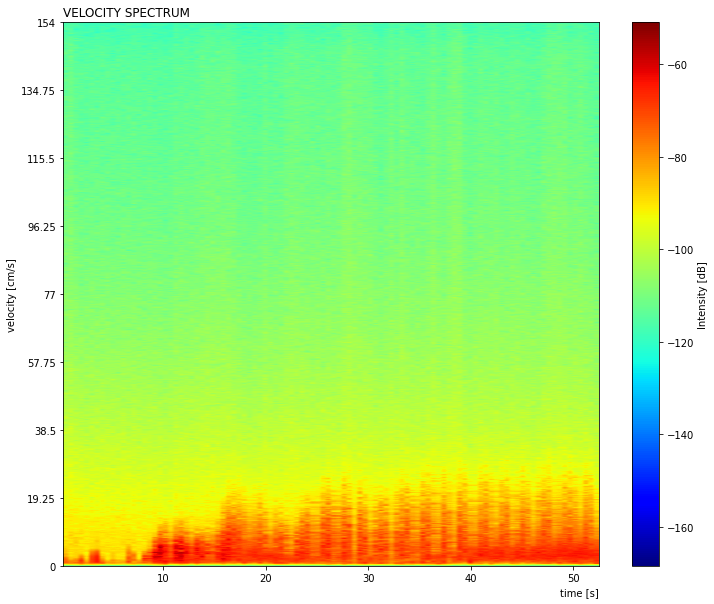

In [10]:
## Plot VELOCITY SPECTRUM
fig, axs = plt.subplots(figsize=(12, 10))
axs.set_title('VELOCITY SPECTRUM',loc='left')
axs.set_xlabel('time [s]',loc='right')
axs.set_ylabel('velocity [cm/s]')
_, _, _, cax = axs.specgram(doppler, NFFT=NFFT, Fs=AUDIO_FS, noverlap=int(NFFT*.5), scale='dB', cmap='jet')
# axs.set_ylim(0,3*F_RANGE)

ticks_y = ticker.FuncFormatter(lambda x, pos: '{0:g}'.format(convert_to_velo(x)))
axs.yaxis.set_major_formatter(ticks_y)

fig.colorbar(cax).set_label('Intensity [dB]')
